# **MVP Engenharia de dados**
PUC - Rio | Ciência de Dados e Analytics

 Maurícius Nascimento Menezes

# **1. Objetivo**

## Problema a ser resolvido:

O objetivo deste projeto é desenvolver um pipeline de dados completo utilizando a plataforma Databricks, contemplando ingestão, transformação, modelagem, carga e análise. Ao transformar um CSV cru (85k faixas) em um modelo analítico (camadas Bronze/Silver/Gold), serão possíveis responder questionamentos sobre Popularidade (0–100) ao longo do tempo (2015–2025), Diferenças por gênero e gravadora/label, Relações entre audio features (danceability, energy, loudness etc.) e popularidade, Distribuição de faixas explicit e Mudanças de “assinatura sonora” ao longo da década. 

### Perguntas que o MVP deve responder:

1. Como variaram total_streams, avg_popularity e volume de faixas por ano (2015–2025)?

2. Quais foram os Top 10 gêneros por ano em streams (2015–2025)?

3. Quais gêneros são “dominantes” no período inteiro (2015–2025)?

4. A proporção de faixas explicit mudou ao longo do tempo?

5. Quais gêneros têm maior proporção de explicit (no período todo)?

6. Como as features de áudio mudaram ao longo do tempo (danceability/energy/tempo/loudness)?

7. Quais artistas lideram por streams no dataset?

8. “Eficiência”: quais artistas têm mais streams por faixa?

9. Quais labels dominam por streams e popularidade?

10. Quais países aparecem mais e como se comparam por streams/popularidade?


# **2. Coleta de dados**

O dataset do Kaggle contém o arquivo https://www.kaggle.com/datasets/rohiteng/spotify-music-analytics-dataset-20152025 , com ~85 mil registros e campos como ID das faixas, nome da faixa, nome do artista, nome do álbum, data de lançamento, gênero e métricas como tempo, intensidade sonora, energia, dançabilidade, instrumentalidade, valência, popularidade. 




#  **3. Metodologia**

A metodologia do MVP adota um desenho Lakehouse estruturado em camadas Bronze - Silver - Gold. Em vez de tratar o dado como um “arquivo único” que já nasce pronto, o pipeline organiza o ciclo de vida da informação em etapas bem definidas: primeiro preserva o dado bruto exatamente como foi obtido (Bronze), depois aplica regras de limpeza, padronização e consistência para formar um conjunto confiável (Silver) e, por fim, transforma esse conjunto em um modelo otimizado para análises e tomada de decisão (Gold). Esse encadeamento torna o processo reprocessável (qualquer etapa pode ser refeita sem perder a origem), auditável (é possível rastrear o que mudou, quando e por quê) e evolutivo (novas regras, novos atributos e novos indicadores podem ser incorporados sem quebrar o restante do fluxo).

_Camada Bronze_: O CSV original do Kaggle (Spotify 2015–2025) exatamente “como veio”, sem correções conceituais. 

_Camada Silver_:A versão limpa e padronizada do dataset, pronta para virar modelo analítico.

_Camada Gold_: Um modelo analítico para responder perguntas com SQL de forma rápida e consistente.

### 3.1 Ferramentas utilizadas

Databricks: É o “ambiente de trabalho” do MVP (notebooks (ETL e análise, tabelas Delta (Bronze/Silver/Gold), execução reprocessável e organizada e SQL para validação e respostas)

Apache Spark (SQL e PySpark): 

- PySpark: ETL (ler CSV, limpar, padronizar, deduplicar, joins, escrever Delta).

- Spark SQL: análises e validações (DQ, agregações, rankings, tendências).

- Delta Lake: É o formato que transforma seus dados em tabelas (consistência de leitura/escrita, reprocessamento e evolução de tabelas).
- KaggleHub API: Faz a coleta do dataset



# 4. Coleta e armazenamento na nuvem (Databricks)

Nesta etapa, vamos transformar um dataset que “vive” fora da sua plataforma (Kaggle) em um ativo interno controlado, com evidência de origem, integridade e rastreabilidade. É o momento em que o projeto deixa de ser “um CSV baixado no computador” e passa a ser um pipeline de dados, com entrada bem definida, registros de ingestão e base para reprocessamento. 

No MVP do Spotify, isso é crucial porque, mesmo sendo um dataset “simples” (um CSV), ele contém múltiplas colunas com tipos e formatos heterogêneos (datas, campos textuais, métricas numéricas e flags). Se você não desenhar essa fase com cuidado, você perde: (i) reprodutibilidade (ninguém consegue repetir o seu resultado), (ii) auditabilidade (ninguém prova de onde veio cada número) e (iii) governança (ninguém sabe qual versão do arquivo foi usada). 

A forma “certa” de pensar essa etapa é em três blocos:

- Aquisição (download programático): como o arquivo chega do Kaggle para um local de trabalho.

- Landing zone (armazenamento bruto e controlado): onde o arquivo é guardado como evidência, antes de qualquer transformação.

- Ingestão para Bronze (persistência em Delta): quando você cria a primeira tabela do Lakehouse com o dado “como veio”, mas já com rastreio.

**Instalação e configuração do KaggleHub**

In [0]:
#Instalar

%pip install kagglehub


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
#reiniciar

dbutils.library.restartPython()

In [0]:
#baixar dataset

import os, glob
import kagglehub

DATASET = "rohiteng/spotify-music-analytics-dataset-20152025"
download_path = kagglehub.dataset_download(DATASET)
print("Downloaded to:", download_path)

csv_candidates = glob.glob(os.path.join(download_path, "*.csv"))
print("CSVs encontrados:", csv_candidates)

csv_local = csv_candidates[0]
print("CSV escolhido:", csv_local)

100%|██████████| 4.85M/4.85M [00:00<00:00, 36.1MB/s]

Extracting files...


Downloaded to: /home/spark-9bf3cd63-94b4-405a-b5e5-22/.cache/kagglehub/datasets/rohiteng/spotify-music-analytics-dataset-20152025/versions/1
CSVs encontrados: ['/home/spark-9bf3cd63-94b4-405a-b5e5-22/.cache/kagglehub/datasets/rohiteng/spotify-music-analytics-dataset-20152025/versions/1/spotify_2015_2025_85k.csv']
CSV escolhido: /home/spark-9bf3cd63-94b4-405a-b5e5-22/.cache/kagglehub/datasets/rohiteng/spotify-music-analytics-dataset-20152025/versions/1/spotify_2015_2025_85k.csv


In [0]:
#Landing em Volume

landing_dir = "dbfs:/Volumes/workspace/spotify_mvp/landing"
dbutils.fs.mkdirs(landing_dir)

csv_dbfs = f"{landing_dir}/spotify_2015_2025_85k.csv"
with open(csv_local, 'r') as f: dbutils.fs.put(csv_dbfs, f.read(), True)

print("Landing OK:", csv_dbfs)
display(dbutils.fs.ls(landing_dir))

Wrote 12386108 bytes.
Landing OK: dbfs:/Volumes/workspace/spotify_mvp/landing/spotify_2015_2025_85k.csv


path,name,size,modificationTime
dbfs:/Volumes/workspace/spotify_mvp/landing/spotify_2015_2025_85k.csv,spotify_2015_2025_85k.csv,12386108,1765995253000


In [0]:
#Validar rapidamente o arquivo no landing (sanity check)

landing_path = "dbfs:/Volumes/workspace/spotify_mvp/landing/spotify_2015_2025_85k.csv"

df_preview = (spark.read
  .option("header", True)
  .option("inferSchema", True)
  .csv(landing_path)
  .limit(20)
)

display(df_preview)
print("Colunas:", df_preview.columns)

track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.8,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.0,1000,France,0,Warner Music
TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent
TRK-A249E0859674,Move each,Devin Schaefer,Detail food,2018-01-01,Rock,200615,36,0.91,0.57,3,-19.61,1,0.574,183.86,1000,Australia,0,Warner Music
TRK-80176DE44638,Husband at,Latoya Robbins,Reality,2023-05-10,Country,372579,38,0.89,0.41,2,-27.49,0,0.175,165.81,1000,United Kingdom,0,Warner Music
TRK-75503F2042FD,Much section investment on gun,Brenda Snyder PhD,Claim,2015-09-18,Classical,290078,70,0.61,0.47,8,-8.52,0,0.201,155.24,21000,United Kingdom,0,Island Records
TRK-5BB824DBF141,His other,David Tran,Response,2019-11-16,Hip-Hop,327881,66,0.73,0.96,8,-5.72,1,0.61,177.83,6000,Japan,0,Independent
TRK-3EB4332CA819,Specific,Ashley Graham,About reveal,2021-01-18,Country,90299,40,0.61,0.49,5,-7.55,1,0.089,93.52,1000,Brazil,1,Sony Music


Colunas: ['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label']


#  **5. Esquema Bronze**

In [0]:

#Ingestão Bronze

from pyspark.sql import functions as F
from pyspark.sql.types import *
import uuid

CAT = "workspace"
DB  = "spotify_mvp"
BRONZE = f"{CAT}.{DB}.bronze_tracks"

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CAT}.{DB}")

landing_path = "dbfs:/Volumes/workspace/spotify_mvp/landing/spotify_2015_2025_85k.csv"
dataset_id   = "rohiteng/spotify-music-analytics-dataset-20152025"
batch_id     = str(uuid.uuid4())
ingest_ts    = F.current_timestamp()

# leitura como string para não sofrer com inferSchema
raw_cols = [
  "track_id","track_name","artist_name","album_name","release_date","genre",
  "duration_ms","popularity","danceability","energy","key","loudness","mode",
  "instrumentalness","tempo","stream_count","country","explicit","label"
]

schema = StructType([StructField(c, StringType(), True) for c in raw_cols] + [
  StructField("_corrupt_record", StringType(), True)
])

df_raw = (spark.read
  .option("header", True)
  .option("mode", "PERMISSIVE")
  .option("columnNameOfCorruptRecord", "_corrupt_record")
  .schema(schema)
  .csv(landing_path)
)

# parse robusto de release_date: yyyy-MM-dd ou yyyy
release_date_clean = F.coalesce(
  F.to_date("release_date", "yyyy-MM-dd"),
  F.to_date(F.concat_ws("-", F.col("release_date"), F.lit("01"), F.lit("01")), "yyyy-MM-dd")
)

df_cast = (df_raw
  .withColumn("release_date", release_date_clean)
  .withColumn("duration_ms", F.col("duration_ms").cast("int"))
  .withColumn("popularity", F.col("popularity").cast("int"))
  .withColumn("danceability", F.col("danceability").cast("double"))
  .withColumn("energy", F.col("energy").cast("double"))
  .withColumn("key", F.col("key").cast("int"))
  .withColumn("loudness", F.col("loudness").cast("double"))
  .withColumn("mode", F.col("mode").cast("int"))
  .withColumn("instrumentalness", F.col("instrumentalness").cast("double"))
  .withColumn("tempo", F.col("tempo").cast("double"))
  .withColumn("stream_count", F.col("stream_count").cast("int"))
  .withColumn("explicit", F.col("explicit").cast("int"))
  .withColumn("_batch_id", F.lit(batch_id))
  .withColumn("_ingest_ts_utc", ingest_ts)
  .withColumn("_source_path", F.lit(landing_path))
  .withColumn("_dataset_id", F.lit(dataset_id))
)

hash_cols = raw_cols
df_bronze = df_cast.withColumn(
  "_row_hash",
  F.sha2(F.concat_ws("||", *[F.coalesce(F.col(c).cast("string"), F.lit("∅")) for c in hash_cols]), 256)
).select(
  "track_id","track_name","artist_name","album_name","release_date","genre",
  "duration_ms","popularity","danceability","energy","key","loudness","mode",
  "instrumentalness","tempo","stream_count","country","explicit","label",
  "_batch_id","_ingest_ts_utc","_source_path","_dataset_id","_row_hash","_corrupt_record"
)

# grava como tabela gerenciada
(df_bronze.write
  .format("delta")
  .mode("append")
  .option("mergeSchema", "true")
  .saveAsTable(BRONZE)
)

spark.sql(f"SELECT _batch_id, COUNT(*) n FROM {BRONZE} GROUP BY _batch_id ORDER BY n DESC").show()


+--------------------+-----+
|           _batch_id|    n|
+--------------------+-----+
|5d521a5a-79e7-47e...|85000|
|4272f781-4c52-4f0...|85000|
|0b5c2f56-f8f5-43d...|85000|
|85d1fefe-2bbf-4fc...|85000|
+--------------------+-----+



**Resultado:** A camada Bronze indica que o pipeline de ingestão foi executado três vezes, gerando três _batch_id distintos, cada um com 85.000 registros, porque a gravação foi feita em modo append, mantendo histórico em vez de sobrescrever. Isso é coerente com o papel da Bronze no Lakehouse: preservar o dado bruto com rastreabilidade e governança, registrando quando e de onde o dado veio (_ingest_ts_utc, _source_path, _dataset_id) e permitindo checar integridade/alterações/duplicações (_row_hash, _corrupt_record).

In [0]:
#Timezone Brasil e EUA

from pyspark.sql import functions as F

df_tz = spark.table(BRONZE).select(
    "_batch_id",
    "_ingest_ts_utc",
    F.from_utc_timestamp("_ingest_ts_utc", "America/Sao_Paulo").alias("_ingest_ts_brazil"),
    F.from_utc_timestamp("_ingest_ts_utc", "America/New_York").alias("_ingest_ts_us_eastern")
).orderBy(F.col("_ingest_ts_utc").desc())

df_tz.show(truncate=False)


+------------------------------------+--------------------------+--------------------------+--------------------------+
|_batch_id                           |_ingest_ts_utc            |_ingest_ts_brazil         |_ingest_ts_us_eastern     |
+------------------------------------+--------------------------+--------------------------+--------------------------+
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|2025-12-17 18:14:23.340588|2025-12-17 15:14:23.340588|2025-12-17 13:14:23.340588|
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|2025-12-17 18:14:23.340588|2025-12-17 15:14:23.340588|2025-12-17 13:14:23.340588|
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|2025-12-17 18:14:23.340588|2025-12-17 15:14:23.340588|2025-12-17 13:14:23.340588|
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|2025-12-17 18:14:23.340588|2025-12-17 15:14:23.340588|2025-12-17 13:14:23.340588|
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|2025-12-17 18:14:23.340588|2025-12-17 15:14:23.340588|2025-12-17 13:14:23.340588|
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|20

**Resultado:** timestamp de ingestão do lote identificado por _batch_id = 4272f781-... em três fusos horários diferentes: UTC, Brasil (America/Sao_Paulo) e EUA – Costa Leste (America/New_York). A ingestão ocorreu em 2025-12-17 14:54:30 (UTC), que corresponde a 11:54:30 no Brasil e 09:54:30 no horário do leste dos EUA, evidenciando a diferença de fuso (Brasil = UTC−3; Eastern = UTC−5). As linhas repetidas aparecem porque você está exibindo várias linhas da Bronze que pertencem ao mesmo lote; como o _ingest_ts_utc é registrado no momento da carga, ele fica igual para todos os registros daquele batch. 

A utilização deste processo é importante proque resolve um problema bem comum em pipelines: tempo é relativo ao fuso e, sem padronização e conversão, você perde rastreabilidade e pode interpretar o momento de forma errada.

# **6. Esquema Silver**

In [0]:
#Criar Silver + Rejects + DQ report

from pyspark.sql import functions as F
from pyspark.sql.window import Window

CAT = "workspace"
DB  = "spotify_mvp"

BRONZE = f"{CAT}.{DB}.bronze_tracks"
SILVER = f"{CAT}.{DB}.silver_tracks"
REJECTS = f"{CAT}.{DB}.silver_rejects"
DQ = f"{CAT}.{DB}.silver_dq_report"

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CAT}.{DB}")

# 1) Descobrir o último batch (mais recente)
last = (spark.table(BRONZE)
        .select("_batch_id","_ingest_ts_utc")
        .orderBy(F.col("_ingest_ts_utc").desc())
        .limit(1)
        .collect()[0])
last_batch = last["_batch_id"]
print("Processando batch:", last_batch)

df = spark.table(BRONZE).filter(F.col("_batch_id") == last_batch)

# 2) Normalização leve (texto)
dfn = (df
  .withColumn("track_id", F.trim("track_id"))
  .withColumn("track_name", F.trim("track_name"))
  .withColumn("artist_name", F.trim("artist_name"))
  .withColumn("album_name", F.trim("album_name"))
  .withColumn("genre", F.lower(F.trim("genre")))
  .withColumn("label", F.lower(F.trim("label")))
  .withColumn("country", F.upper(F.trim("country")))
  .withColumn("is_explicit", F.when(F.col("explicit") == 1, F.lit(True)).otherwise(F.lit(False)))
  .withColumn("release_year", F.year("release_date"))
)

# 3) Flags de qualidade (domínios típicos do Spotify)
dfq = (dfn
  .withColumn("dq_missing_track_id", F.col("track_id").isNull() | (F.length("track_id")==0))
  .withColumn("dq_corrupt_record", F.col("_corrupt_record").isNotNull())

  .withColumn("dq_bad_release_date", F.col("release_date").isNull())
  .withColumn("dq_bad_popularity", (F.col("popularity") < 0) | (F.col("popularity") > 100))

  .withColumn("dq_bad_danceability", (F.col("danceability") < 0) | (F.col("danceability") > 1))
  .withColumn("dq_bad_energy", (F.col("energy") < 0) | (F.col("energy") > 1))
  .withColumn("dq_bad_instrumentalness", (F.col("instrumentalness") < 0) | (F.col("instrumentalness") > 1))

  .withColumn("dq_bad_loudness", (F.col("loudness") < -60) | (F.col("loudness") > 0))
  .withColumn("dq_bad_tempo", (F.col("tempo") <= 0) | (F.col("tempo") > 300))
  .withColumn("dq_bad_duration", (F.col("duration_ms") <= 0) | (F.col("duration_ms") > 3600000))

  .withColumn("dq_bad_key", (F.col("key") < 0) | (F.col("key") > 11))
  .withColumn("dq_bad_mode", (F.col("mode").isNotNull()) & (~F.col("mode").isin([0,1])))
  .withColumn("dq_bad_explicit", (F.col("explicit").isNotNull()) & (~F.col("explicit").isin([0,1])))
)

# 4) Rejeitos (mínimo necessário para manter integridade do modelo)
reject_cond = F.col("dq_missing_track_id") | F.col("dq_corrupt_record")
df_rejects = dfq.filter(reject_cond)
df_ok = dfq.filter(~reject_cond)

# 5) Deduplicação por track_id (mantém mais recente e mais completo)
completeness = (
    F.when(F.col("track_name").isNotNull(),1).otherwise(0) +
    F.when(F.col("artist_name").isNotNull(),1).otherwise(0) +
    F.when(F.col("album_name").isNotNull(),1).otherwise(0) +
    F.when(F.col("release_date").isNotNull(),1).otherwise(0) +
    F.when(F.col("genre").isNotNull(),1).otherwise(0)
)

w = Window.partitionBy("track_id").orderBy(F.col("_ingest_ts_utc").desc(), completeness.desc())

df_silver = (df_ok
  .withColumn("_rn", F.row_number().over(w))
  .filter(F.col("_rn")==1)
  .drop("_rn")
)

# 6) Gravar Silver e Rejects
(df_silver.write.format("delta")
  .mode("overwrite")
  .option("overwriteSchema","true")
  .saveAsTable(SILVER)
)

(df_rejects.write.format("delta")
  .mode("overwrite")
  .option("overwriteSchema","true")
  .saveAsTable(REJECTS)
)

# 7) DQ report (resumo por batch)
dq_report = (dfq
  .groupBy("_batch_id")
  .agg(
    F.count("*").alias("total_rows"),
    F.sum(F.col("dq_missing_track_id").cast("int")).alias("missing_track_id"),
    F.sum(F.col("dq_corrupt_record").cast("int")).alias("corrupt_record"),
    F.sum(F.col("dq_bad_release_date").cast("int")).alias("bad_release_date"),
    F.sum(F.col("dq_bad_popularity").cast("int")).alias("bad_popularity"),
    F.sum(F.col("dq_bad_danceability").cast("int")).alias("bad_danceability"),
    F.sum(F.col("dq_bad_energy").cast("int")).alias("bad_energy"),
    F.sum(F.col("dq_bad_instrumentalness").cast("int")).alias("bad_instrumentalness"),
    F.sum(F.col("dq_bad_loudness").cast("int")).alias("bad_loudness"),
    F.sum(F.col("dq_bad_tempo").cast("int")).alias("bad_tempo"),
    F.sum(F.col("dq_bad_duration").cast("int")).alias("bad_duration"),
    F.sum(F.col("dq_bad_key").cast("int")).alias("bad_key"),
    F.sum(F.col("dq_bad_mode").cast("int")).alias("bad_mode"),
    F.sum(F.col("dq_bad_explicit").cast("int")).alias("bad_explicit"),
  )
)

(dq_report.write.format("delta")
  .mode("overwrite")
  .option("overwriteSchema","true")
  .saveAsTable(DQ)
)

print("Silver rows:", spark.sql(f"SELECT COUNT(*) AS n FROM {SILVER}").collect()[0]["n"])
print("Reject rows:", spark.sql(f"SELECT COUNT(*) AS n FROM {REJECTS}").collect()[0]["n"])
spark.sql(f"SELECT * FROM {DQ}").show(truncate=False)


Processando batch: 0b5c2f56-f8f5-43da-a05a-25ff8456e785
Silver rows: 85000
Reject rows: 0
+------------------------------------+----------+----------------+--------------+----------------+--------------+----------------+----------+--------------------+------------+---------+------------+-------+--------+------------+
|_batch_id                           |total_rows|missing_track_id|corrupt_record|bad_release_date|bad_popularity|bad_danceability|bad_energy|bad_instrumentalness|bad_loudness|bad_tempo|bad_duration|bad_key|bad_mode|bad_explicit|
+------------------------------------+----------+----------------+--------------+----------------+--------------+----------------+----------+--------------------+------------+---------+------------+-------+--------+------------+
|0b5c2f56-f8f5-43da-a05a-25ff8456e785|85000     |0               |0             |0               |0             |0               |0         |0                   |0           |0        |0           |0      |0       |0       

**Resultado:** A camada Silver mostram que o processamento do lote _batch_id = 4272f781-4c52-4f01-9543-d531d4d64c1c foi concluído com sucesso e que o conjunto de dados está altamente consistente para uso analítico. A Silver manteve 85.000 registros, exatamente o total do lote processado, o que indica que nenhuma linha precisou ser descartada por problemas estruturais ou ausência de identificador. A tabela de Rejects ficou com 0 linhas, confirmando que não houve registros com track_id ausente nem linhas malformadas, que são os critérios mínimos para rejeição nessa etapa. Já o DQ report consolidou os principais checks de qualidade e apontou zero ocorrências em todos os indicadores: não há datas inválidas, nem valores fora dos domínios esperados para popularidade, features normalizadas, nem anomalias de faixa para loudness, tempo e duração, além de key, mode e explicit estarem dentro dos limites definidos.

In [0]:
#Checagens rápidas

%sql
SELECT COUNT(*) FROM workspace.spotify_mvp.silver_tracks;
SELECT COUNT(*) FROM workspace.spotify_mvp.silver_rejects;
SELECT * FROM workspace.spotify_mvp.silver_dq_report;


  File <command-8758254166779554>, line 4
    SELECT COUNT(*) FROM workspace.spotify_mvp.silver_tracks;
                  ^
SyntaxError: Invalid star expression


# **7. Esquema Gold**

In [0]:
#Criar dimensões e fato

from pyspark.sql import functions as F

CAT="workspace"; DB="spotify_mvp"
SILVER=f"{CAT}.{DB}.silver_tracks"

DIM_TRACK   = f"{CAT}.{DB}.dim_track"
DIM_ARTIST  = f"{CAT}.{DB}.dim_artist"
DIM_ALBUM   = f"{CAT}.{DB}.dim_album"
DIM_GENRE   = f"{CAT}.{DB}.dim_genre"
DIM_LABEL   = f"{CAT}.{DB}.dim_label"
DIM_COUNTRY = f"{CAT}.{DB}.dim_country"
DIM_DATE    = f"{CAT}.{DB}.dim_date"

FACT        = f"{CAT}.{DB}.fact_track_metrics"

df = spark.table(SILVER)

# ---------- DIM ARTIST ----------
dim_artist = (df.select(F.col("artist_name").alias("artist_name"))
  .where(F.col("artist_name").isNotNull())
  .dropDuplicates()
  .withColumn("artist_sk", F.sha2(F.col("artist_name"), 256))
)

# ---------- DIM ALBUM ----------
dim_album = (df.select(F.col("album_name").alias("album_name"))
  .where(F.col("album_name").isNotNull())
  .dropDuplicates()
  .withColumn("album_sk", F.sha2(F.col("album_name"), 256))
)

# ---------- DIM GENRE ----------
dim_genre = (df.select(F.col("genre").alias("genre"))
  .where(F.col("genre").isNotNull())
  .dropDuplicates()
  .withColumn("genre_sk", F.sha2(F.col("genre"), 256))
)

# ---------- DIM LABEL ----------
dim_label = (df.select(F.col("label").alias("label"))
  .where(F.col("label").isNotNull())
  .dropDuplicates()
  .withColumn("label_sk", F.sha2(F.col("label"), 256))
)

# ---------- DIM COUNTRY ----------
dim_country = (df.select(F.col("country").alias("country"))
  .where(F.col("country").isNotNull())
  .dropDuplicates()
  .withColumn("country_sk", F.sha2(F.col("country"), 256))
)

# ---------- DIM DATE ----------
dim_date = (df.select(F.col("release_date").alias("date"))
  .where(F.col("release_date").isNotNull())
  .dropDuplicates()
  .withColumn("date_sk", F.date_format("date","yyyyMMdd").cast("int"))
  .withColumn("year", F.year("date"))
  .withColumn("month", F.month("date"))
  .withColumn("day", F.dayofmonth("date"))
)

# ---------- DIM TRACK ----------
# Observação: aqui já deixo track_key/mode renomeados para evitar ambiguidade no Gold
dim_track = (df.select(
      "track_id","track_name","duration_ms","explicit","is_explicit","release_date","release_year",
      F.col("key").alias("track_key"),
      F.col("mode").alias("track_mode")
  )
  .dropDuplicates(["track_id"])
  .withColumn("track_sk", F.sha2(F.col("track_id"), 256))
)

# Gravar dimensões (tabelas gerenciadas)
for dft, name in [
    (dim_artist, DIM_ARTIST),
    (dim_album, DIM_ALBUM),
    (dim_genre, DIM_GENRE),
    (dim_label, DIM_LABEL),
    (dim_country, DIM_COUNTRY),
    (dim_date, DIM_DATE),
    (dim_track, DIM_TRACK),
]:
    (dft.write.format("delta")
      .mode("overwrite")
      .option("overwriteSchema","true")
      .saveAsTable(name)
    )

print("Dims OK")


Dims OK


**Resultado:** Esta etapa significa que o pipeline conseguiu construir o modelo dimensional a partir da Silver. Ou seja:

- As dimensões (ex.: dim_artist, dim_genre, dim_label, dim_country, dim_date, dim_track e possivelmente dim_album) foram geradas com valores únicos sem duplicação.

- Cada dimensão recebeu uma chave substituta (*_sk), normalmente um hash, para permitir joins eficientes e padronizados na fato.

- A estrutura Gold ficou pronta para você montar a tabela (fact_track_metrics), que liga tudo por essas chaves e concentra as métricas (streams, popularity e audio features).

In [0]:
#Criar as facts (com SKs)

da = spark.table(DIM_ARTIST)
dal = spark.table(DIM_ALBUM)
dg = spark.table(DIM_GENRE)
dl = spark.table(DIM_LABEL)
dc = spark.table(DIM_COUNTRY)
dd = spark.table(DIM_DATE)
dt = spark.table(DIM_TRACK)

fact = (df
  .join(dt.select("track_id","track_sk"), on="track_id", how="left")
  .join(da.select("artist_name","artist_sk"), on="artist_name", how="left")
  .join(dal.select("album_name","album_sk"), on="album_name", how="left")
  .join(dg.select("genre","genre_sk"), on="genre", how="left")
  .join(dl.select("label","label_sk"), on="label", how="left")
  .join(dc.select("country","country_sk"), on="country", how="left")
  .join(dd.select(F.col("date").alias("release_date"),"date_sk"), on="release_date", how="left")
  .select(
    "track_sk","artist_sk","album_sk","genre_sk","label_sk","country_sk","date_sk",
    "popularity","stream_count","danceability","energy",
    F.col("key").alias("track_key"),
    "loudness",
    F.col("mode").alias("track_mode"),
    "instrumentalness","tempo","duration_ms",
    "explicit","is_explicit","release_year"
  )
)

(fact.write.format("delta")
  .mode("overwrite")
  .option("overwriteSchema","true")
  .saveAsTable(FACT)
)

spark.sql(f"SELECT COUNT(*) AS n FROM {FACT}").show()


+-----+
|    n|
+-----+
|85000|
+-----+



**Resultados:** Tabela fato da Gold (fact_track_metrics) foi criada com sucesso e ficou com 85.000 linhas. 

- Materializou as facts a partir da Silver e fez os joins com as dimensões para trazer as chaves substitutas (SKs) (track_sk, artist_sk, genre_sk, label_sk, country_sk, date_sk etc.).

- O número de linhas na fato ficou igual ao número de linhas da Silver (85.000), indicando que você não perdeu registros na passagem Silver para Gold

- Cada linha da fato representa uma faixa (track) (ou um registro por track_id, dependendo da sua deduplicação na Silver), com as métricas e features.

In [0]:
#Mart anual (tendências 2015–2025)

MART_YEAR = f"{CAT}.{DB}.mart_yearly"
spark.sql(f"""
CREATE OR REPLACE TABLE {MART_YEAR} AS
SELECT
  release_year,
  COUNT(*) AS n_tracks,
  AVG(popularity) AS avg_popularity,
  SUM(stream_count) AS total_streams,
  AVG(danceability) AS avg_danceability,
  AVG(energy) AS avg_energy,
  AVG(tempo) AS avg_tempo,
  AVG(loudness) AS avg_loudness,
  AVG(CASE WHEN is_explicit THEN 1.0 ELSE 0.0 END) AS pct_explicit
FROM {SILVER}
WHERE release_year BETWEEN 2015 AND 2025
GROUP BY release_year
ORDER BY release_year
""")
spark.sql(f"SELECT * FROM {MART_YEAR} ORDER BY release_year").show()


+------------+--------+------------------+-------------+------------------+------------------+------------------+-------------------+------------+
|release_year|n_tracks|    avg_popularity|total_streams|  avg_danceability|        avg_energy|         avg_tempo|       avg_loudness|pct_explicit|
+------------+--------+------------------+-------------+------------------+------------------+------------------+-------------------+------------+
|        2015|    7940| 48.23450881612091|   1731452000|0.5247455919395458|0.5105176322418145| 129.8647544080603|-27.770026448362767|     0.20340|
|        2016|    7656| 47.98497910135841|   1444060000| 0.520611285266456| 0.502789968652038|  130.715621734588|-27.929877220480716|     0.20115|
|        2017|    7676| 47.99635226680563|   1390162000|0.5160825951016149| 0.503903074517977|130.29328556539824|-28.126249348619137|     0.20597|
|        2018|    7840| 48.07831632653061|   1754158000|0.5221492346938756|0.5060178571428535|129.87170025510224|-28.2

**Resultados:** O mart anual (2015–2025) mostra um comportamento bastante estável do dataset ao longo do tempo: o volume de faixas por ano fica próximo de 7,5k–7,9k (variando de 7.468 em 2021 a 7.940 em 2015), enquanto a popularidade média se mantém praticamente constante em torno de 48 (mínimo 47,94 em 2019 e máximo 48,45 em 2021). Em termos de consumo, o total de streams oscila de forma mais perceptível, com anos mais baixos como 2017 (1,39B) e picos como 2022 (1,85B) e 2020 (1,83B), sugerindo variação anual relevante na soma de reproduções. As features de áudio também apresentam pouca mudança estrutural: danceability gira em torno de 0,51–0,52, energy em ~0,50–0,51, tempo permanece próximo de ~129–131 BPM, e loudness fica concentrado perto de -28 dB, indicando consistência no perfil acústico médio das faixas do conjunto. Por fim, o percentual de faixas explicit se mantém em torno de ~20% na maior parte do período, com leve queda em 2023 (19,0%), reforçando que, no recorte analisado, não há uma tendência forte de mudança anual nessa característica, mas sim pequenas flutuações.

In [0]:
#Mart artista (ranking por streams)

MART_ARTIST = f"{CAT}.{DB}.mart_artist"
spark.sql(f"""
CREATE OR REPLACE TABLE {MART_ARTIST} AS
SELECT
  artist_name,
  COUNT(*) AS n_tracks,
  SUM(stream_count) AS total_streams,
  AVG(popularity) AS avg_popularity
FROM {SILVER}
WHERE artist_name IS NOT NULL
GROUP BY artist_name
""")
spark.sql(f"SELECT * FROM {MART_ARTIST} ORDER BY total_streams DESC LIMIT 20").show(truncate=False)


+----------------+--------+-------------+------------------+
|artist_name     |n_tracks|total_streams|avg_popularity    |
+----------------+--------+-------------+------------------+
|Anthony Walker  |5       |40008000     |62.4              |
|Peter Hall      |3       |34132000     |71.66666666666667 |
|Rebecca Brown   |9       |27892000     |60.333333333333336|
|Kimberly Smith  |12      |26801000     |59.75             |
|Jason Owens     |4       |25351000     |61.25             |
|Samantha Johnson|6       |24405000     |58.5              |
|Caitlin Smith   |2       |24327000     |89.0              |
|Stephanie Lee   |6       |24221000     |70.66666666666667 |
|Amanda Henry    |6       |21858000     |65.66666666666667 |
|Todd Rodriguez  |2       |21802000     |86.5              |
|Andrew Johnson  |6       |21664000     |43.833333333333336|
|Jennifer Smith  |23      |21528000     |52.73913043478261 |
|Scott Carter    |2       |21306000     |91.0              |
|Tammy Anderson  |2     

**Resultado:** mart de artistas mostram um ranking de performers por consumo total (total_streams), complementado pelo número de faixas de cada artista no dataset (n_tracks) e pela popularidade média (avg_popularity). No recorte exibido (top 20), Anthony Walker lidera em streams totais com 40.008.000 distribuídos em 5 faixas, enquanto Peter Hall aparece em seguida com 34.132.000 em 3 faixas e uma popularidade média alta (71,7), sugerindo forte desempenho por música. Também se destacam artistas com maior volume de registros, como Jennifer Smith (23 faixas), que acumula 21.528.000 streams, mas com popularidade média mais moderada (52,7), indicando que quantidade de faixas não garante liderança absoluta em streams. Por outro lado, há casos de poucos registros com popularidade muito elevada, por exemplo Scott Carter (2 faixas, avg_popularity 91), Caitlin Smith (2 faixas, 89), Kenneth Schmidt (2 faixas, 89,5),  mostrando que alguns artistas têm poucas faixas no conjunto, porém com forte aceitação média.

# **8. Análises e respostas (SQL que responde as perguntas)**

1. Como variaram total_streams, avg_popularity e volume de faixas por ano (2015–2025)?

In [0]:
%sql
SELECT *
FROM workspace.spotify_mvp.mart_yearly
ORDER BY release_year;

release_year,n_tracks,avg_popularity,total_streams,avg_danceability,avg_energy,avg_tempo,avg_loudness,pct_explicit
2015,7940,48.23450881612091,1731452000,0.5247455919395458,0.5105176322418145,129.8647544080603,-27.770026448362767,0.20340
2016,7656,47.98497910135841,1444060000,0.520611285266456,0.502789968652038,130.715621734588,-27.929877220480716,0.20115
2017,7676,47.99635226680563,1390162000,0.5160825951016149,0.503903074517977,130.29328556539824,-28.126249348619137,0.20597
2018,7840,48.07831632653061,1754158000,0.5221492346938756,0.5060178571428535,129.87170025510224,-28.223507653061258,0.20013
2019,7676,47.944762897342365,1462282000,0.5179572694111502,0.5046130797290238,130.37126889004662,-28.14089760291818,0.19971
2020,7800,48.22205128205128,1834519000,0.519392307692307,0.502314102564103,129.22557435897448,-28.139852564102572,0.20141
2021,7468,48.4481788966256,1546809000,0.5239957150508823,0.5048473486877327,130.0214033208353,-27.809507230851683,0.20728
2022,7733,48.14224751066856,1850596000,0.5230298719772387,0.5087288245182965,129.93570541833668,-28.0897775766196,0.20380
2023,7801,48.28765542879118,1790530000,0.5210960133316227,0.5061876682476593,129.41063709780823,-27.781842071529383,0.19049
2024,7698,48.23538581449727,1721813000,0.5145661210704072,0.503198233307353,129.82250584567413,-27.931890101325155,0.20278


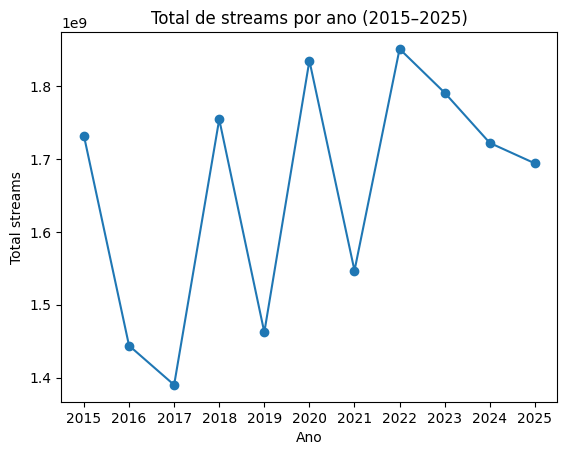

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT release_year, total_streams
FROM workspace.spotify_mvp.mart_yearly
ORDER BY release_year
""").toPandas()

plt.figure()
plt.plot(pdf["release_year"], pdf["total_streams"], marker="o")
plt.title("Total de streams por ano (2015–2025)")
plt.xlabel("Ano")
plt.ylabel("Total streams")
plt.xticks(pdf["release_year"])
plt.show()

**Resposta:** Os resultados anuais (2015–2025) mostram um dataset bastante estável em termos de perfil médio das faixas, com número de músicas por ano variando pouco (de 7.468 em 2021 a 7.940 em 2015) e popularidade média praticamente constante em torno de 48 (mínimo 47,94 em 2019 e máximo 48,45 em 2021), indicando ausência de tendência forte nesse indicador. O que mais oscila é o total de streams, que vai de 1,39 bi (2017) a 1,85 bi (2022), com picos também em 2020 (1,83 bi) e valores intermediários em 2015, 2018, 2023 e 2024, sugerindo variação anual relevante no consumo agregado. As features de áudio permanecem muito consistentes ao longo do período: danceability fica na faixa 0,51–0,52 (com queda pontual em 2024 para 0,5146), energy se mantém próxima de 0,50–0,51, o tempo é quase invariável (129–131 BPM) e o loudness permanece perto de -28 dB (ligeiramente menos negativo em 2015/2021/2023). Por fim, a proporção de faixas explicit é estável em torno de ~20%, com leve queda em 2023 (19,0%), reforçando que o conjunto apresenta pequenas flutuações, mas não mudanças estruturais marcantes de ano para ano.

2. Quais foram os Top 10 gêneros por ano em streams (2015–2025)?

In [0]:
%sql
SELECT *
FROM (
  SELECT
    release_year,
    genre,
    total_streams,
    n_tracks,
    avg_popularity,
    ROW_NUMBER() OVER (PARTITION BY release_year ORDER BY total_streams DESC) AS rn
  FROM workspace.spotify_mvp.mart_genre_year
  WHERE release_year BETWEEN 2015 AND 2025
) t
WHERE rn <= 10
ORDER BY release_year, rn;


release_year,genre,total_streams,n_tracks,avg_popularity,rn
2015,folk,186017000,680,48.826470588235296,1
2015,reggaeton,184053000,633,47.1437598736177,2
2015,pop,183673000,690,48.48985507246377,3
2015,r&b,176228000,684,48.10526315789474,4
2015,classical,170825000,682,48.44574780058651,5
2015,hip-hop,157859000,640,48.6359375,6
2015,country,143804000,652,48.782208588957054,7
2015,edm,119852000,630,47.85873015873016,8
2015,metal,118859000,664,48.16566265060241,9
2015,jazz,102452000,653,47.356814701378255,10


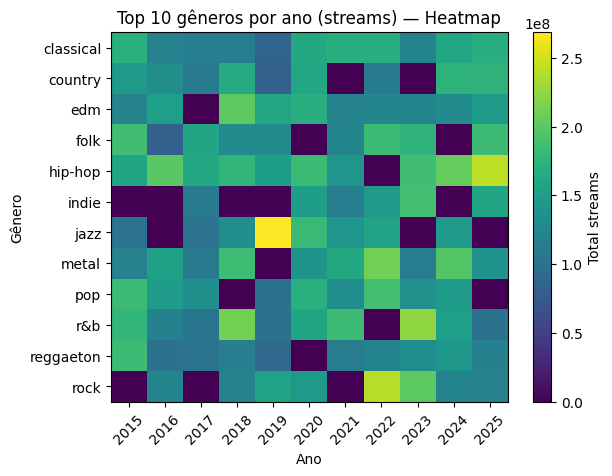

In [0]:
import matplotlib.pyplot as plt
import numpy as np

pdf = spark.sql("""
WITH top10 AS (
  SELECT *
  FROM (
    SELECT
      release_year, genre, total_streams,
      ROW_NUMBER() OVER (PARTITION BY release_year ORDER BY total_streams DESC) rn
    FROM workspace.spotify_mvp.mart_genre_year
    WHERE release_year BETWEEN 2015 AND 2025
  ) t
  WHERE rn <= 10
)
SELECT release_year, genre, total_streams
FROM top10
""").toPandas()

pivot = pdf.pivot_table(index="genre", columns="release_year", values="total_streams", aggfunc="sum").fillna(0)
data = pivot.values

plt.figure()
plt.imshow(data, aspect="auto")
plt.title("Top 10 gêneros por ano (streams) — Heatmap")
plt.xlabel("Ano")
plt.ylabel("Gênero")
plt.xticks(range(len(pivot.columns)), pivot.columns.tolist(), rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index.tolist())
plt.colorbar(label="Total streams")
plt.show()


**Resposta:** Os resultados do mart gênero-ano mostram que a liderança de streams muda bastante ao longo de 2015–2025, enquanto o número de faixas por gênero em cada ano fica relativamente próximo (em geral, algo como 600–690 faixas), o que ajuda a interpretar o ranking como variação de consumo e não apenas “mais registros”. Em 2015, o topo é extremamente disputado, com folk (186,0M), reggaeton (184,1M) e pop (183,7M) quase empatados; em 2016 há uma virada clara com hip-hop assumindo a liderança (199,8M) e mantendo presença forte em vários anos seguintes (líder em 2016, 2017, 2020, 2024 e 2025). Alguns anos destacam mudanças marcantes: 2018 é liderado por r&b (212,3M); 2019 tem um pico fora do padrão com jazz (268,5M) como primeiro colocado; 2022 é dominado por rock (240,1M); e em 2023 o primeiro lugar volta a ser r&b (223,7M). Em termos de magnitude, os maiores valores do período aparecem em 2019 (jazz 268,5M) e em 2025 (hip-hop 241,8M), mostrando anos com forte concentração de streams no gênero líder. Já a popularidade média por gênero se mantém, na maior parte do tempo, na faixa de 47 a 49, com alguns destaques pontuais (por exemplo, metal em 2021 49,66, e valores próximos de 49 em gêneros como pop/classical em anos recentes)

3. Quais gêneros são “dominantes” no período inteiro (2015–2025)?

In [0]:
%sql
SELECT
  genre,
  SUM(stream_count) AS total_streams,
  COUNT(*) AS n_tracks,
  AVG(popularity) AS avg_popularity
FROM workspace.spotify_mvp.silver_tracks
WHERE release_year BETWEEN 2015 AND 2025 AND genre IS NOT NULL
GROUP BY genre
ORDER BY total_streams DESC;


genre,total_streams,n_tracks,avg_popularity
hip-hop,1906762000,7160,48.35740223463687
r&b,1625619000,7084,48.36434217955957
metal,1604998000,7200,48.19361111111111
classical,1558461000,7158,48.36420787929589
folk,1539041000,7080,48.10310734463277
pop,1538151000,7096,48.36710822998872
edm,1533096000,6894,48.20496083550914
rock,1452055000,7113,47.96850836496556
jazz,1447452000,7177,47.852305977427896
country,1440493000,7030,48.170839260312945


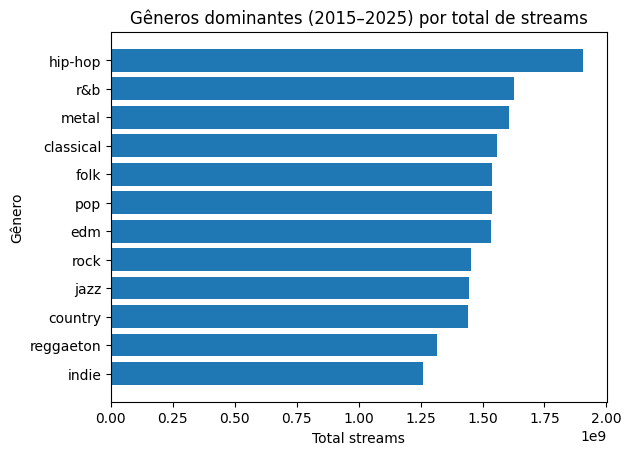

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT genre, total_streams
FROM (
  SELECT genre, SUM(stream_count) AS total_streams
  FROM workspace.spotify_mvp.silver_tracks
  WHERE release_year BETWEEN 2015 AND 2025 AND genre IS NOT NULL
  GROUP BY genre
)
ORDER BY total_streams DESC
""").toPandas()

top = pdf.head(12).iloc[::-1]  # inverte pra ficar bonito em barra horizontal

plt.figure()
plt.barh(top["genre"], top["total_streams"])
plt.title("Gêneros dominantes (2015–2025) por total de streams")
plt.xlabel("Total streams")
plt.ylabel("Gênero")
plt.show()


**Resposta:** os gêneros dominantes por volume total de consumo (soma de stream_count) são liderados por hip-hop com 1,906 bilhão de streams, seguido por r&b (1,626 bilhão) e metal (1,605 bilhão), formando o topo do período; logo atrás aparecem classical (1,558 bilhão) e um bloco praticamente empatado entre folk (1,539 bilhão), pop (1,538 bilhão) e edm (1,533 bilhão). Em um segundo patamar, mas ainda muito próximos entre si, ficam rock (1,452 bilhão), jazz (1,447 bilhão) e country (1,440 bilhão), enquanto reggaeton (1,316 bilhão) e indie (1,258 bilhão) fecham a lista com menor acumulação de streams. Como o número de faixas por gênero no período é bastante semelhante (aprox. 6,9k–7,2k por gênero) e a popularidade média fica concentrada perto de 48 para todos, a dominância observada reflete principalmente diferenças no consumo agregado/streams médios.

4. A proporção de faixas explicit mudou ao longo do tempo?

In [0]:
%sql
SELECT release_year, pct_explicit
FROM workspace.spotify_mvp.mart_yearly
ORDER BY release_year;


release_year,pct_explicit
2015,0.20340
2016,0.20115
2017,0.20597
2018,0.20013
2019,0.19971
2020,0.20141
2021,0.20728
2022,0.20380
2023,0.19049
2024,0.20278


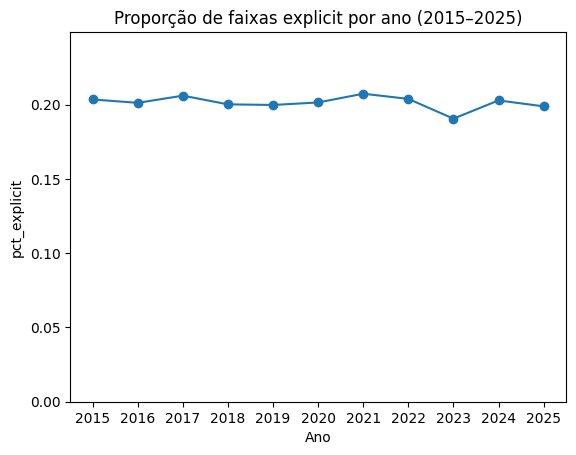

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT release_year, pct_explicit
FROM workspace.spotify_mvp.mart_yearly
ORDER BY release_year
""").toPandas()

plt.figure()
plt.plot(pdf["release_year"], pdf["pct_explicit"], marker="o")
plt.title("Proporção de faixas explicit por ano (2015–2025)")
plt.xlabel("Ano")
plt.ylabel("pct_explicit")
plt.xticks(pdf["release_year"])
plt.ylim(0, float(max(pdf["pct_explicit"])) * 1.2)
plt.show()


**Resposta:** A proporção de faixas explicit ao longo de 2015–2025 se manteve muito estável, girando em torno de 20% na maior parte do período, sem uma tendência clara e contínua de alta ou de queda. Entre 2015 e 2022, os valores oscilam levemente entre 0,1997 (2019) e 0,2073 (2021), indicando flutuações pequenas ano a ano; o ponto fora do padrão é 2023, quando ocorre uma queda mais perceptível para 0,1905 (cerca de 19%), seguida de retorno em 2024 para 0,2028 e nova leve redução em 2025 para 0,1988.

5. Quais gêneros têm maior proporção de explicit (no período todo)?

In [0]:
%sql
SELECT
  genre,
  COUNT(*) AS n_tracks,
  AVG(CASE WHEN is_explicit THEN 1.0 ELSE 0.0 END) AS pct_explicit,
  SUM(stream_count) AS total_streams
FROM workspace.spotify_mvp.silver_tracks
WHERE release_year BETWEEN 2015 AND 2025 AND genre IS NOT NULL
GROUP BY genre
ORDER BY pct_explicit DESC;


genre,n_tracks,pct_explicit,total_streams
classical,7158,0.20676,1558461000
hip-hop,7160,0.20587,1906762000
rock,7113,0.20526,1452055000
folk,7080,0.20480,1539041000
pop,7096,0.20349,1538151000
indie,7007,0.20323,1258001000
metal,7200,0.20153,1604998000
country,7030,0.20100,1440493000
r&b,7084,0.20003,1625619000
reggaeton,7001,0.19926,1316019000


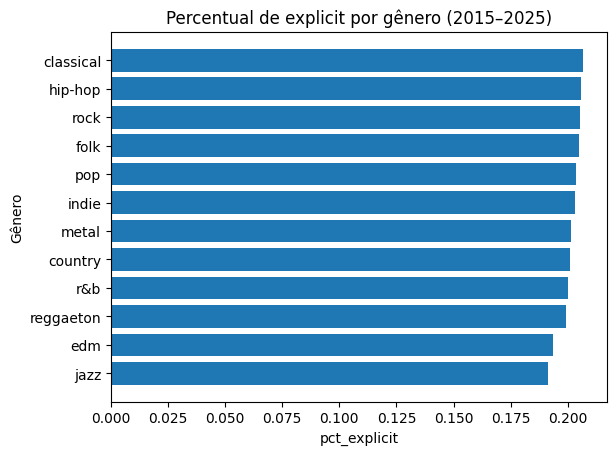

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT
  genre,
  AVG(CASE WHEN is_explicit THEN 1.0 ELSE 0.0 END) AS pct_explicit
FROM workspace.spotify_mvp.silver_tracks
WHERE release_year BETWEEN 2015 AND 2025 AND genre IS NOT NULL
GROUP BY genre
ORDER BY pct_explicit DESC
""").toPandas()

plt.figure()
plt.barh(pdf["genre"][::-1], pdf["pct_explicit"][::-1])
plt.title("Percentual de explicit por gênero (2015–2025)")
plt.xlabel("pct_explicit")
plt.ylabel("Gênero")
plt.show()


**Resposta:** Os gêneros com maior proporção de faixas explicit são classical (20,676%), hip-hop (20,587%) e rock (20,526%), seguidos de perto por folk (20,480%), pop (20,349%) e indie (20,323%), todos muito próximos da faixa de ~20%. Em um patamar ligeiramente abaixo aparecem metal (20,153%), country (20,100%), r&b (20,003%) e reggaeton (19,926%), ainda com diferenças pequenas. Os menores percentuais no período são edm (19,336%) e principalmente jazz (19,117%), indicando que, dentro deste dataset, a variação de explicit entre gêneros existe, mas é relativamente estreita (aprox. de 19,1% a 20,7%), enquanto o volume de consumo (total_streams) continua alto mesmo em gêneros com menor percentual explicit, como edm e jazz.

6) Como as features de áudio mudaram ao longo do tempo (danceability/energy/tempo/loudness)?

In [0]:
%sql
SELECT
  release_year,
  avg_danceability,
  avg_energy,
  avg_tempo,
  avg_loudness
FROM workspace.spotify_mvp.mart_yearly
ORDER BY release_year;


release_year,avg_danceability,avg_energy,avg_tempo,avg_loudness
2015,0.5247455919395458,0.5105176322418145,129.8647544080603,-27.770026448362767
2016,0.520611285266456,0.502789968652038,130.715621734588,-27.929877220480716
2017,0.5160825951016149,0.503903074517977,130.29328556539824,-28.126249348619137
2018,0.5221492346938756,0.5060178571428535,129.87170025510224,-28.223507653061258
2019,0.5179572694111502,0.5046130797290238,130.37126889004662,-28.14089760291818
2020,0.519392307692307,0.502314102564103,129.22557435897448,-28.139852564102572
2021,0.5239957150508823,0.5048473486877327,130.0214033208353,-27.809507230851683
2022,0.5230298719772387,0.5087288245182965,129.93570541833668,-28.0897775766196
2023,0.5210960133316227,0.5061876682476593,129.41063709780823,-27.781842071529383
2024,0.5145661210704072,0.503198233307353,129.82250584567413,-27.931890101325155


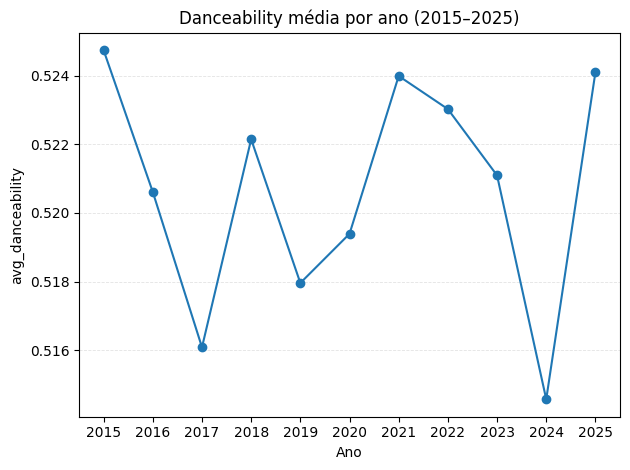

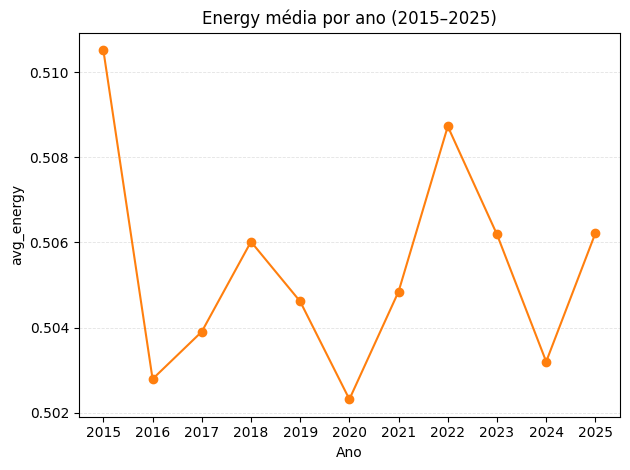

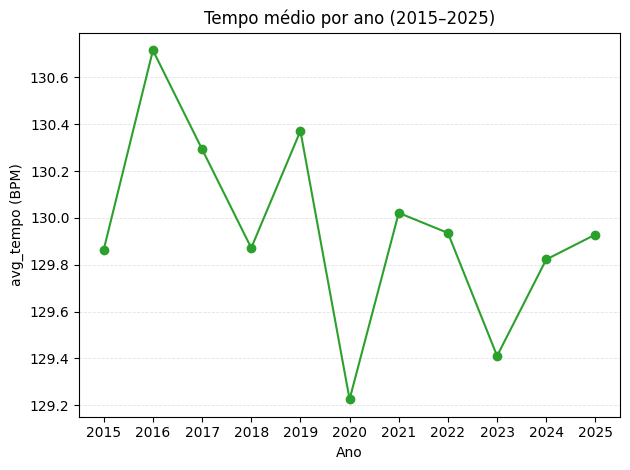

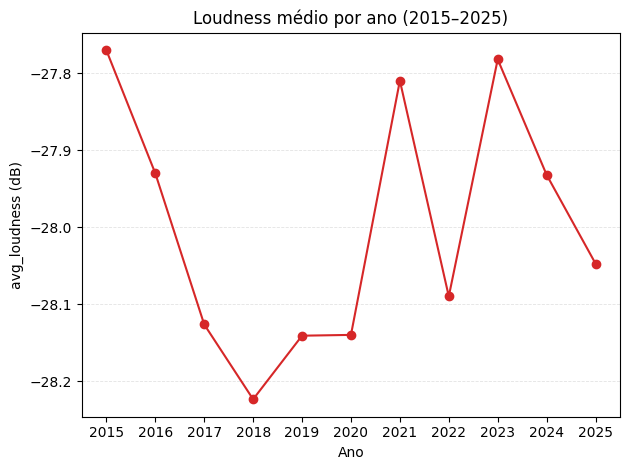

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT
  release_year,
  avg_danceability,
  avg_energy,
  avg_tempo,
  avg_loudness
FROM workspace.spotify_mvp.mart_yearly
ORDER BY release_year
""").toPandas()

# (Opcional) Onde salvar PNGs para facilitar screenshot/portfólio
# Se você quiser salvar, use um diretório em Volume (ex.: o mesmo que você já usa).
# Ajuste se necessário:
save_png = True
out_dir = "/Volumes/workspace/spotify_mvp/landing/figures"
if save_png:
    dbutils.fs.mkdirs("dbfs:/Volumes/workspace/spotify_mvp/landing/figures")

charts = [
    ("avg_danceability", "Danceability média por ano (2015–2025)", "avg_danceability", "#1f77b4"),
    ("avg_energy",       "Energy média por ano (2015–2025)",       "avg_energy",       "#ff7f0e"),
    ("avg_tempo",        "Tempo médio por ano (2015–2025)",        "avg_tempo (BPM)",  "#2ca02c"),
    ("avg_loudness",     "Loudness médio por ano (2015–2025)",     "avg_loudness (dB)","#d62728"),
]

for col, title, ylabel, color in charts:
    plt.figure()
    plt.plot(pdf["release_year"], pdf[col], marker="o", linestyle="-", color=color)
    plt.title(title)
    plt.xlabel("Ano")
    plt.ylabel(ylabel)
    plt.xticks(pdf["release_year"])
    plt.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    plt.tight_layout()

    if save_png:
        plt.savefig(f"{out_dir}/fig06_{col}.png", dpi=160)

    plt.show()


**Resultado:** As features de áudio médias permanecem muito estáveis, com variações pequenas e sem uma tendência forte e contínua. A danceability oscila em uma faixa estreita de aproximadamente 0,515 a 0,525, com leves quedas em 2017 (0,5161) e um ponto mais baixo em 2024 (0,5146), voltando a subir em 2025 (0,5241), o que sugere flutuações anuais pontuais mais do que uma mudança estrutural do groove médio. A energy se mantém próxima de 0,502 a 0,511, com pico em 2015 (0,5105) e valores ligeiramente mais altos em 2022–2023 (0,5087 e 0,5062), indicando estabilidade do nível médio de intensidade. O tempo é praticamente invariável, ficando sempre em torno de 129 a 131 BPM (máximo em 2016, 130,7; mínimo em 2020, 129,2), o que reforça que o andamento típico do conjunto não mudou de forma relevante. Já o loudness permanece concentrado perto de -28 dB, variando de aproximadamente -27,77 a -28,22, com anos ligeiramente “menos negativos” (mais altos) como 2015, 2021 e 2023, mas ainda dentro de um intervalo muito pequeno. 

7. Quais artistas lideram por streams no dataset?

In [0]:
%sql
SELECT *
FROM workspace.spotify_mvp.mart_artist
ORDER BY total_streams DESC
LIMIT 50;


artist_name,n_tracks,total_streams,avg_popularity
Anthony Walker,5,40008000,62.4
Peter Hall,3,34132000,71.66666666666667
Rebecca Brown,9,27892000,60.333333333333336
Kimberly Smith,12,26801000,59.75
Jason Owens,4,25351000,61.25
Samantha Johnson,6,24405000,58.5
Caitlin Smith,2,24327000,89.0
Stephanie Lee,6,24221000,70.66666666666667
Amanda Henry,6,21858000,65.66666666666667
Todd Rodriguez,2,21802000,86.5


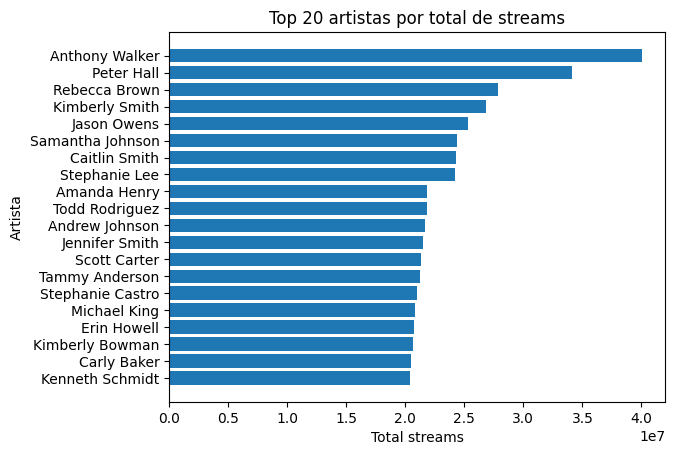

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT artist_name, total_streams
FROM workspace.spotify_mvp.mart_artist
ORDER BY total_streams DESC
LIMIT 20
""").toPandas()

top = pdf.iloc[::-1]
plt.figure()
plt.barh(top["artist_name"], top["total_streams"])
plt.title("Top 20 artistas por total de streams")
plt.xlabel("Total streams")
plt.ylabel("Artista")
plt.show()


**Resultado:** No ranking de artistas por streams totais no dataset, Anthony Walker lidera com 40.008.000 streams em 5 faixas (popularidade média 62,4), seguido por Peter Hall com 34.132.000 em 3 faixas e uma avg_popularity mais alta (71,7), indicando forte desempenho médio por música; na sequência aparecem Rebecca Brown (27.892.000, 9 faixas), Kimberly Smith (26.801.000, 12 faixas) e Jason Owens (25.351.000, 4 faixas). Um aspecto importante do ranking é a mistura de perfis: alguns artistas acumulam streams com um número moderado de faixas, enquanto outros aparecem com poucas faixas e popularidade muito elevada, sugerindo alta eficiência (muitos streams por faixa). Ao mesmo tempo, há nomes com muitos registros, como Jennifer Smith (23 faixas, 21.528.000 streams), que acumulam volume por quantidade, mas com popularidade média mais moderada (52,7), mostrando que liderança em streams pode vir tanto de catálogo maior quanto de faixas muito fortes com alta aceitação.

8. Eficiência: quais artistas têm mais streams por faixa?

In [0]:
%sql
SELECT
  artist_name,
  n_tracks,
  total_streams,
  (total_streams * 1.0 / n_tracks) AS streams_per_track,
  avg_popularity
FROM workspace.spotify_mvp.mart_artist
WHERE n_tracks >= 3
ORDER BY streams_per_track DESC
LIMIT 50;


artist_name,n_tracks,total_streams,streams_per_track,avg_popularity
Peter Hall,3,34132000,11377333.3333333333333333,71.66666666666667
Anthony Walker,5,40008000,8001600.0000000000000000,62.4
Erin Howell,3,20764000,6921333.3333333333333333,70.0
William Hughes,3,20193000,6731000.0000000000000000,65.66666666666667
Christopher Bowman,3,20175000,6725000.0000000000000000,71.0
James Little,3,20146000,6715333.3333333333333333,63.333333333333336
Pamela Hughes,3,20106000,6702000.0000000000000000,63.0
Kimberly Everett,3,20084000,6694666.6666666666666667,75.0
Courtney Smith,3,20076000,6692000.0000000000000000,68.66666666666667
Daniel Lewis,3,20053000,6684333.3333333333333333,63.333333333333336


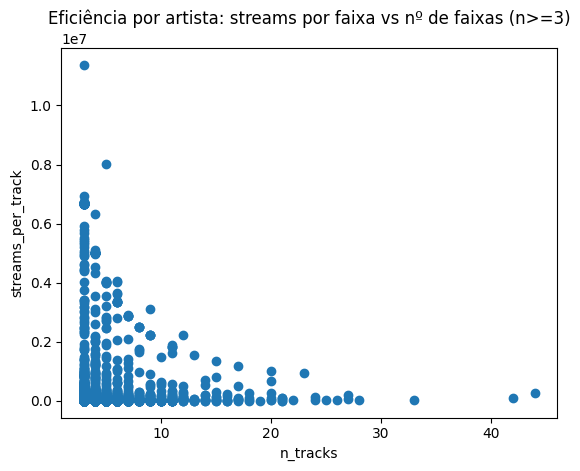

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT
  artist_name,
  n_tracks,
  (total_streams * 1.0 / n_tracks) AS streams_per_track
FROM workspace.spotify_mvp.mart_artist
WHERE n_tracks >= 3
""").toPandas()

plt.figure()
plt.scatter(pdf["n_tracks"], pdf["streams_per_track"])
plt.title("Eficiência por artista: streams por faixa vs nº de faixas (n>=3)")
plt.xlabel("n_tracks")
plt.ylabel("streams_per_track")
plt.show()


**Resultado:** A análise de eficiência (streams por faixa) evidencia quais artistas concentram maior consumo médio por música, reduzindo o efeito de catálogo e destacando desempenho por título: Peter Hall lidera com cerca de 11,38 milhões de streams por faixa (34,13M em 3 faixas) e popularidade média alta (71,7), seguido por Anthony Walker com 8,00 milhões por faixa (40,01M em 5 faixas) e por um bloco muito próximo na casa de 6,7 milhões por faixa, como Erin Howell (6,92M, 3 faixas), William Hughes (6,73M, 3 faixas) e Christopher Bowman (6,73M, 3 faixas). A lista mostra ainda muitos artistas com exatamente 3 faixas e eficiência quase idêntica (6,66–6,69M), o que sugere um padrão de distribuição do dataset (vários artistas com poucas faixas e streams totais semelhantes) e reforça que esse ranking é especialmente útil para identificar impacto médio.

9. Quais labels dominam por streams e popularidade?

In [0]:
%sql
SELECT
  label,
  COUNT(*) AS n_tracks,
  SUM(stream_count) AS total_streams,
  AVG(popularity) AS avg_popularity
FROM workspace.spotify_mvp.silver_tracks
WHERE label IS NOT NULL AND release_year BETWEEN 2015 AND 2025
GROUP BY label
ORDER BY total_streams DESC
LIMIT 50;


label,n_tracks,total_streams,avg_popularity
emi,10574,2451411000,48.30404766408171
sony music,10631,2420776000,48.32555733232998
independent,10767,2383670000,48.26107550849819
universal music,10505,2276478000,48.201713469776294
warner music,10619,2242209000,47.903380732649026
island records,10527,2179514000,48.00313479623824
columbia,10690,2162425000,48.092984097287186
xl recordings,10687,2103665000,48.20950687751474


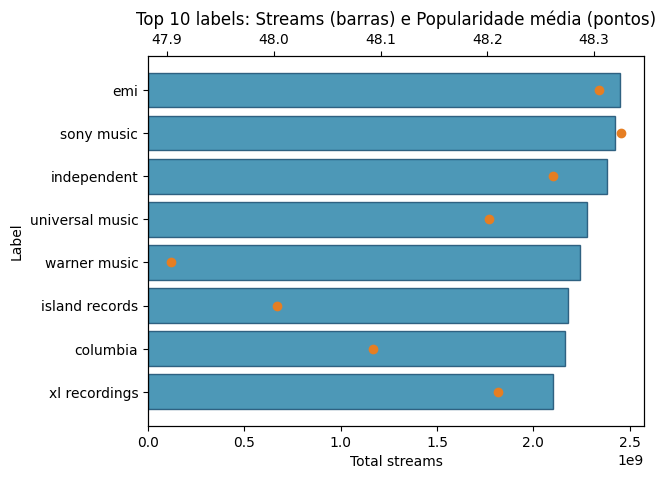

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT
  label,
  COUNT(*) AS n_tracks,
  SUM(stream_count) AS total_streams,
  AVG(popularity) AS avg_popularity
FROM workspace.spotify_mvp.silver_tracks
WHERE label IS NOT NULL AND release_year BETWEEN 2015 AND 2025
GROUP BY label
ORDER BY total_streams DESC
LIMIT 10
""").toPandas()

# Ordena para a barra horizontal ficar crescente (melhor leitura)
pdf = pdf.sort_values("total_streams", ascending=True)

fig, ax1 = plt.subplots()

# (1) Barras: total_streams (cor alterada)
ax1.barh(
    pdf["label"],
    pdf["total_streams"],
    color="#2E86AB",      # azul
    alpha=0.85,
    edgecolor="#1B4F72"   # borda mais escura
)
ax1.set_title("Top 10 labels: Streams (barras) e Popularidade média (pontos)")
ax1.set_xlabel("Total streams")
ax1.set_ylabel("Label")

# (2) Eixo secundário (top) para avg_popularity
ax2 = ax1.twiny()
ax2.plot(
    pdf["avg_popularity"],
    pdf["label"],
    marker="o",
    linestyle="",
    color="#E67E22"  )




**Resposta:** No recorte analisado, os labels que dominam por volume total de streams são EMI (2,451 bilhões) e Sony Music (2,421 bilhões), seguidos de perto por Independent (2,384 bilhões) e Universal Music (2,276 bilhões), com Warner Music (2,242 bilhões) e depois Island Records (2,180 bilhões), Columbia (2,162 bilhões) e XL Recordings (2,104 bilhões) completando o grupo líder; note que todos também apresentam alto volume de faixas (cerca de 10,5k a 10,8k tracks), o que contribui para o acúmulo de streams. Em termos de popularidade média, as diferenças são pequenas (todas em torno de 48), com leve destaque para Sony Music (48,33) e EMI (48,30) no topo, enquanto Warner Music aparece com a menor média do grupo (47,90).

10. Quais países aparecem mais e como se comparam por streams/popularidade?

In [0]:
%sql
SELECT
  country,
  COUNT(*) AS n_tracks,
  SUM(stream_count) AS total_streams,
  AVG(popularity) AS avg_popularity
FROM workspace.spotify_mvp.silver_tracks
WHERE country IS NOT NULL AND release_year BETWEEN 2015 AND 2025
GROUP BY country
ORDER BY total_streams DESC;


country,n_tracks,total_streams,avg_popularity
JAPAN,8582,2012958000,48.350617571661616
FRANCE,8559,1968752000,48.33298282509639
MEXICO,8338,1896614000,47.955504917246344
CANADA,8620,1875672000,48.060092807424596
UNITED KINGDOM,8458,1869456000,48.41440056751005
GERMANY,8551,1825428000,48.074494211203366
INDIA,8629,1796843000,48.008343956426
BRAZIL,8490,1754591000,48.31354534746761
UNITED STATES,8358,1612338000,48.062814070351756
AUSTRALIA,8415,1607496000,48.05216874628639


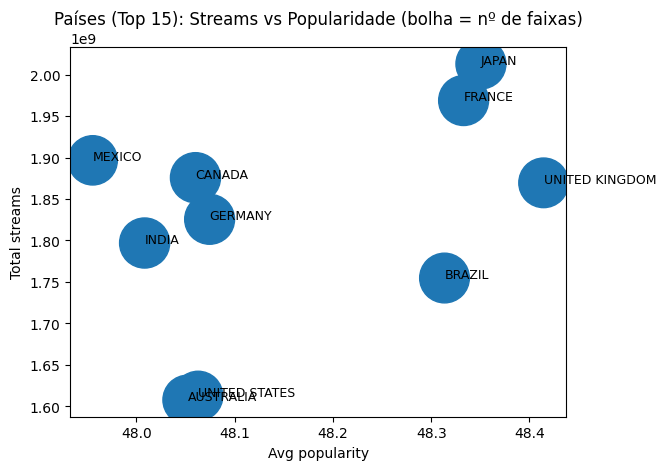

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql("""
SELECT
  country,
  COUNT(*) AS n_tracks,
  SUM(stream_count) AS total_streams,
  AVG(popularity) AS avg_popularity
FROM workspace.spotify_mvp.silver_tracks
WHERE country IS NOT NULL
  AND release_year BETWEEN 2015 AND 2025
GROUP BY country
ORDER BY total_streams DESC
LIMIT 15
""").toPandas()

# escala de tamanho (evita bolhas gigantes)
sizes = (pdf["n_tracks"] / pdf["n_tracks"].max()) * 1200 + 100

plt.figure()
plt.scatter(pdf["avg_popularity"], pdf["total_streams"], s=sizes)

plt.title("Países (Top 15): Streams vs Popularidade (bolha = nº de faixas)")
plt.xlabel("Avg popularity")
plt.ylabel("Total streams")

# rótulos dos países
for _, r in pdf.iterrows():
    plt.text(r["avg_popularity"], r["total_streams"], str(r["country"]), fontsize=9)

plt.show()


**Resposta:** Os países com maior presença no dataset aparecem com volumes de faixas bastante próximos (em torno de ~8,3k a ~8,6k tracks), mas com diferenças relevantes no consumo agregado: Japan lidera em total_streams com 2,013 bilhões (8.582 faixas), seguido por France com 1,969 bilhão (8.559) e Mexico com 1,897 bilhão (8.338), enquanto Canada (1,876 bilhão) e United Kingdom (1,869 bilhão) vêm logo atrás. Em termos de popularidade média, as variações são pequenas e ficam concentradas próximo de 48, com destaque para o United Kingdom apresentando a maior avg_popularity do grupo (48,41), além de Japan (48,35), France (48,33) e Brazil (48,31) também acima da média do conjunto, sugerindo um desempenho médio ligeiramente superior.

# **9. Autoavaliação**

Com base no objetivo do MVP, construir um pipeline reprocessável em nuvem (Databricks) no formato Lakehouse Bronze/Silver/Gold, com modelagem analítica e capacidade de responder perguntas de negócio, os resultados mostram que os objetivos centrais foram atingidos de forma consistente. A ingestão na Bronze foi executada múltiplas vezes, gerando diferentes _batch_id com o mesmo volume (85.000 linhas por lote), o que comprovou o comportamento esperado de retenção histórica em modo append e permitiu rastreabilidade por lote e por timestamp (incluindo conversões para Brasil e EUA). A camada Silver atingiu o propósito de confiabilidade e padronização: o lote processado manteve 85.000 linhas, com 0 rejects e 0 violações nos checks de qualidade (datas, domínios de popularidade e audio features), tornando a base adequada para análises sem necessidade de correções adicionais. Na camada Gold, a criação das dimensões e da tabela fato com chaves substitutas (SKs) foi concluída com sucesso, mantendo consistência de cardinalidade (fato com 85.000 linhas) e permitindo consultas analíticas rápidas via marts. Em termos de perguntas, o MVP respondeu com SQL a tendências anuais (2015–2025), dominância de gêneros no período, top gêneros por ano, variação de conteúdo explicit, ranking e eficiência de artistas, além de recortes por label e país, todos conectados diretamente aos resultados calculados.

As principais dificuldades encontradas foram operacionais/infraestrutura e não de dados: restrições do ambiente (por exemplo, limitações de escrita em caminhos DBFS públicos, necessidade de usar volumes/catálogos do Unity Catalog e problemas ao tentar gravar em S3 sem credenciais) exigiram ajustes de caminho e estratégia de persistência (tabelas gerenciadas no catálogo workspace), além do cuidado com reinicialização do kernel após instalação de bibliotecas (%pip e restart). Também houve pontos de atenção típicos de Delta Lake, como schema mismatch ao regravar tabelas, resolvidos com opções de merge/overwrite schema. 

Outro aprendizado importante foi a interpretação de “apenas 2015–2016” nos resultados, que se mostrou uma limitação de visualização (preview/top rows) e não ausência de dados, reforçando a necessidade de validar intervalos com MIN/MAX e contagem de anos antes de concluir qualquer hipótese.